In [3]:
def calculate_pareto_front(points):
    sorted_points = sorted(points, key=lambda x: x['auc'], reverse=True)
    pareto_front = []
    max_time = float('inf')
    
    for point in sorted_points:
        if point['predict_time_per_row_ms'] < max_time:
            pareto_front.append(point)
            max_time = point['predict_time_per_row_ms']
    
    return pareto_front


In [4]:
import pandas as pd

df_H10h1 = pd.read_csv("./H10h1.csv")
df_H10h3 = pd.read_csv("./H10h3.csv")
df_H10h5 = pd.read_csv("./H10h5.csv")


In [5]:
from pprint import pprint

colors = {'StackedEnsemble': 'red', 'XGBoost': 'blue', 'GBM': 'green', 'DRF': 'orange', 'DeepLearning': 'purple', 'GLM': 'yellow'}

def get_points_from_df(df):
    points = []
    for index, row in df.iterrows():
        color = None
        if row['algo'] in colors.keys():
            color = colors[row['algo']]
        else:
            color = 'gray'
        point = {
            'model_id': row['model_id'],
            'auc':row['auc'],
            'predict_time_per_row_ms': row['predict_time_per_row_ms'],
            'algo':row['algo'],
            'color':color
            }
        points.append(point)
    return points

In [6]:
points_H10h1 = get_points_from_df(df_H10h1)
points_H10h3 = get_points_from_df(df_H10h3)
points_H10h5 = get_points_from_df(df_H10h5)

pareto_front_H10h1 = calculate_pareto_front(points_H10h1)
pareto_front_H10h3 = calculate_pareto_front(points_H10h3)
pareto_front_H10h5 = calculate_pareto_front(points_H10h5)


In [9]:
import matplotlib.pyplot as plt

def plot_pareto_front(ax, points, pareto_front):
    
    unique_algo_values = set(item["algo"] for item in points)
    #fig, ax = plt.subplots()

    for algo in unique_algo_values:
        filtered_list = list(filter(lambda item: item["algo"] == algo, points))
        x = [item["predict_time_per_row_ms"] for item in filtered_list]
        y = [item["auc"] for item in filtered_list]
        color = [item["color"] for item in filtered_list]
        ax.scatter(x, y, c=color, label=algo,
                alpha=0.6, edgecolors='none')
        ax.legend(algo)
        ax.set_xlabel("Predict time per row")
        ax.set_ylabel("AUC")

    pareto_time_values = [item["predict_time_per_row_ms"] for item in pareto_front]
    pareto_auc_values = [item["auc"] for item in pareto_front]
    
    ax.plot(pareto_time_values, pareto_auc_values, c='red', label='Pareto Front')
    
    legends = list(unique_algo_values)
    legends.append('Pareto Front')
    legend = ax.legend()
    legend.get_frame().set_alpha(1)
    ax.legend(legends, loc='lower right', bbox_to_anchor=(1.0, 0.0))
    ax.grid(True)

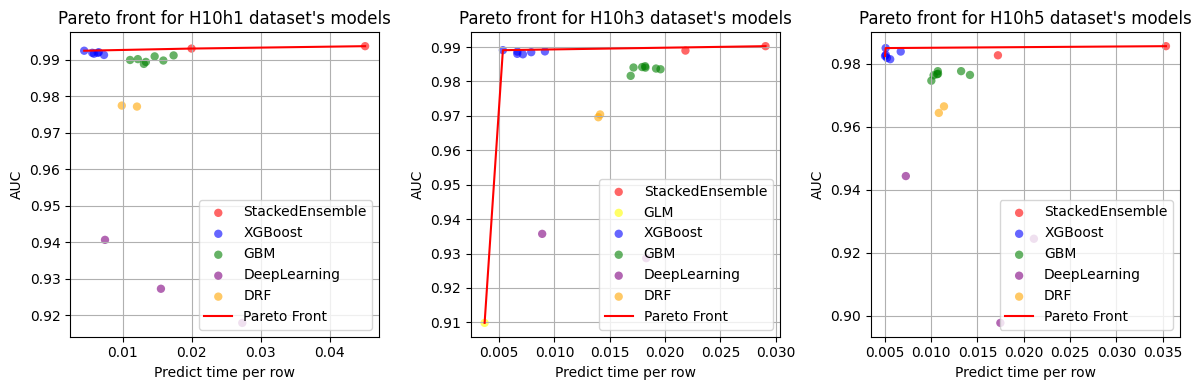

In [10]:
# Crear la figura y los subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

plot_pareto_front(ax1,points_H10h1, pareto_front_H10h1)
ax1.set_title('Pareto front for H10h1 dataset\'s models')

plot_pareto_front(ax2,points_H10h3, pareto_front_H10h3)
ax2.set_title('Pareto front for H10h3 dataset\'s models')

plot_pareto_front(ax3,points_H10h5, pareto_front_H10h5)
ax3.set_title('Pareto front for H10h5 dataset\'s models')

# Ajustar los espacios entre subplots
plt.tight_layout()

# Mostrar el gráfico
plt.show()
